## Importations : 

In [1]:
import datetime
import lightgbm as lgb
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import plotly
import pandas as pd
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import plotly.express as px


import scipy
from scipy.stats import normaltest
import seaborn as sns
import sklearn
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error,  mean_absolute_percentage_error, r2_score
#from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn import linear_model

from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
import sys

import time
#%matplotlib inline

import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

# Versions
print('Version des librairies utilisées :')

print('NumPy                 : ' + np.version.full_version)
print('Pandas                : ' + pd.__version__)
print('Python                : ' + sys.version)
print('Plotly                : ' + plotly.__version__)
#print('Matplotlib            : ' + mpl.__version__)
print('Scipy                 : '+ scipy.__version__)
print('Seaborn               : ' + sns.__version__)
print('Sklearn               : ' + sklearn.__version__)
#print('jyquickhelper         : ' + jyquickhelper.__version__)

Version des librairies utilisées :
NumPy                 : 1.21.5
Pandas                : 1.4.2
Python                : 3.9.12 (main, Apr  4 2022, 05:22:27) [MSC v.1916 64 bit (AMD64)]
Plotly                : 5.6.0
Scipy                 : 1.7.3
Seaborn               : 0.11.2
Sklearn               : 1.3.0


In [3]:
#Chargement des données nettoyées
data=pd.read_csv('building_energy_propre.csv')

In [4]:
data.describe()


,Unnamed: 0,BuildingAge,ENERGYSTARScore,SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),RateParking,RateBuilding,RatePerFloors,RatePerBuildings,RateLargestPropertyUseType,RateSecondLargestPropertyUseType,RateThirdLargestPropertyUseType,NumberOfAllUseTypes,haversine_distance,TotalGHGEmissionsLog,SiteEnergyUse(kBtu)Log
count,3367.000000,3367.000000,2533.000000,3367.000000,3367.000000,3367.000000,3367.000000,3367.000000,3.367000e+03,3.367000e+03,3367.000000,3367.000000,3367.000000,3367.000000,3367.000000,3367.000000,3367.000000
mean,1683.000000,47.425898,67.918674,0.038610,0.995842,0.626374,0.041485,0.958515,2.463661e+04,8.821247e+04,0.878121,0.110835,0.015707,1.784378,4.771205,1.548081,6.300360
std,972.113505,33.101005,26.873271,0.192692,0.064358,0.483838,0.114891,0.114891,5.406684e+04,1.439001e+05,0.256841,0.157600,0.049958,1.067182,3.680804,0.624677,0.682491
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.105000,3.115200e+03,4.300000e+03,0.000000,0.000000,0.000000,1.000000,0.019653,0.000000,0.000000
25%,841.500000,19.000000,53.000000,0.000000,1.000000,0.000000,0.000000,1.000000,8.649083e+03,2.787700e+04,0.743850,0.000000,0.000000,1.000000,1.628662,1.020982,5.967278
50%,1683.000000,41.000000,75.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.402600e+04,4.338000e+04,0.985300,0.000000,0.000000,1.000000,3.694187,1.543074,6.256831
75%,2524.500000,68.000000,90.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.633486e+04,8.781050e+04,1.000000,0.206100,0.000000,2.000000,7.119037,1.977449,6.625839
max,3366.000000,116.000000,100.000000,1.000000,1.000000,1.000000,0.895000,1.000000,2.330039e+06,2.200000e+06,6.426800,1.452100,0.929100,12.000000,14.444195,4.227166,8.941474


In [5]:
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0', axis=1, inplace=True)

In [6]:
#copie pour suivi et comparaison
data_initial= data.copy()

In [7]:
data.dtypes


BuildingType                         object
PrimaryPropertyType                  object
PropertyName                         object
Neighborhood                         object
LargestPropertyUseType               object
SecondLargestPropertyUseType         object
ThirdLargestPropertyUseType          object
BuildingAge                           int64
ENERGYSTARScore                     float64
SteamUse(kBtu)                      float64
Electricity(kBtu)                   float64
NaturalGas(kBtu)                    float64
RateParking                         float64
RateBuilding                        float64
RatePerFloors                       float64
RatePerBuildings                    float64
RateLargestPropertyUseType          float64
RateSecondLargestPropertyUseType    float64
RateThirdLargestPropertyUseType     float64
NumberOfAllUseTypes                   int64
haversine_distance                  float64
TotalGHGEmissionsLog                float64
SiteEnergyUse(kBtu)Log          

## Preprocessing


In [10]:
seed= 42


Il nous reste une variable d'identification, elle nous a servi pour l'analyse exploratoire.
Nous n'avons plus besoin de ce type de variable.

In [9]:
data.drop("PropertyName" , axis = 1, inplace= True)


## Dataset pour le choix de modèle


In [16]:
## Suppression de la colonne 'ENERGYSTARScore' pour la modélisation

model_data = data.drop(columns = "ENERGYSTARScore")



Les variables numériques et catégorielles doivent etre standardisées et encodées. Pour ce faire nous devons les identifier.


In [17]:
model_data.dropna(how = 'any', inplace=True)


## Choix des modèles utilisés : 

Linéaire : ElasticNet

>Méthode de régression régularisée qui combine linéairement les pénalités L1 et L2 des méthodes Lasso et Ridge. 
>La régularisation consiste à contrôler simultanément l'erreur du modèle sur le jeu d'entraînement et la complexité du modèle.


>La méthode du Elastic Net surmonte les limites de Lasso qui utilise une fonction de pénalité (L1) qui permet d'avoir un modèle >parcimonieux (avec beaucoup de coefficients nuls) mais instable. 
>D'autre part, Lasso n'a pas de solution explicite ni nécessairement unique. 

>Pour surmonter ces limitations, l'Elastic Net ajoute la régularisation de Tikhonov connue aussi comme Régression Ridge (L2) qui >permet d'éviter le sur-apprentissage avec une solution unique.

>Elastic Net combine les normes L1 et L2 pour obtenir une solution moins parcimonieuse que Lasso mais plus stable et dans <laquelle toutes les variables corrélées pertinentes pour la prédiction de l'étiquette sont sélectionnées et reçoivent un poids >identique.




**Ensembliste** :

 **RandomForest** : 
>technique capable d'effectuer à la fois des tâches de régression et de classification à l'aide de plusieurs arbres de décision >et de la technique Bootstrap Agreggation (bagging : entraîner chaque arbre de décision sur un jeu de données différent où >l'échantillonnage est effectué avec remplacement). 

>L'idée derrière cette méthode est de combiner plusieurs arbres de décision pour déterminer le résultat final plutôt que de >s'appuyer sur des arbres de décision individuels.
  
  
  **LightGBM**
>algorithme basé sur les arbres de décisions avec la particularité de développer l'arbre verticalement. Donc feuilles par >feuilles au lieu de niveau par niveau. Il a pour avantage de converger plus rapidement.



**non-linéaire** : 

**SVR** 
>technique d'apprentissage automatique qui peut être utilisée à la fois pour des problèmes de régression et de classification. >Il construit un hyperplan dans un espace multidimensionnel pour séparer un jeu de données en différentes classes de la >meilleure façon possible ; donc, l'hyperplan c'est un plan de décision qui sépare et classe un ensemble de données.

>Les problèmes de régression impliquent la tâche d'approximer une fonction de mappage de variables d'entrée à une variable de >sortie continue.

>L'approche consistant à utiliser les SVM pour résoudre les problèmes de régression est appelée Support Vector Regression (SVR).

>Le SVM reconnaît l'hyperplan optimal en calculant la distance entre le plan et les vecteurs de support (les points de données >les plus proches de l'hyperplan), appelée la Marge (Margin).
>L'hyperplan optimal est le plan qui a la distance maximale des points de données les plus proches de chaque côté.

# Modèles pour les émissions de CO2


## Baseline 

In [28]:
#timeit pour mesurer le temps d'exécution et suivre la performance 
def timed(f):
    def timed(*args, **kw):

        ts = time.time()
        result = f(*args, **kw)
        te = time.time()

        print (f"Durée d'exécution de {f.__name__}: {te-ts}s")
        return result

    return timed

In [30]:
# Fonction de régression avec validation croisée

@timed
def regression(model,name,X,y):
    metrics = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2']
    score = cross_validate(model,X,y,cv=10, scoring = metrics, return_train_score = True)
   # Calcul des métriques et création du dictionnaire avec les résultats 
    dico = {
        'modèle ': [name],
        'Fit time': [score['fit_time'].mean()],
        'Durée': [score['score_time'].mean()],
        'Test R2': [score['test_r2'].mean()],
        'Train R2': [score['train_r2'].mean()],
        'Test RMSE': [np.sqrt(- (score['train_neg_mean_squared_error'].mean()))],
        'Test MAE': [- (score['train_neg_mean_absolute_error'].mean())],
        'Train RMSE': [np.sqrt(- (score['train_neg_mean_squared_error'].mean()))],
        'Train MAE': [- (score['train_neg_mean_absolute_error'].mean())]
         }
        
   # Conversion en DataFrame pour une présentation lisible

    df_dico = pd.DataFrame(dico)
    return df_dico

In [32]:
@timed
def compare_resultat(X_train,y_train):
    resultats = pd.DataFrame()
    model =[]
  # Modèles à tester
  
    model.append(('linear_regression', linear_model.LinearRegression()))
    model.append(('elastic net', linear_model.ElasticNet(random_state=seed)))
    model.append(('random_forest', RandomForestRegressor(random_state=seed)))
    model.append(('svr', SVR()))
    model.append(('LGBM', lgb.LGBMRegressor()))
       
    for name, mod in model: 
        res = regression(mod, name, X_train, y_train)
        resultats = pd.concat([resultats,res], ignore_index=True)
    return resultats.style.hide_index()


In [41]:
baseline_co2 = compare_resultat(X_Co2_train, y_Co2_train)
baseline_co2

Durée d'exécution de regression: 0.18741345405578613s
Durée d'exécution de regression: 0.18546271324157715s
Durée d'exécution de regression: 84.49816131591797s
Durée d'exécution de regression: 11.976579666137695s
Durée d'exécution de regression: 12.695143461227417s
Durée d'exécution de compare_resultat: 109.64791250228882s


modèle,Fit time,Durée,Test R2,Train R2,Test RMSE,Test MAE,Train RMSE,Train MAE
linear_regression,0.008109,0.004178,0.658186,0.674307,0.354405,0.267223,0.354405,0.267223
elastic net,0.005168,0.007896,0.102654,0.106679,0.586953,0.486056,0.586953,0.486056
random_forest,8.337265,0.028960,0.756630,0.966016,0.114482,0.082126,0.114482,0.082126
svr,0.412304,0.078553,0.735558,0.777358,0.293027,0.209943,0.293027,0.209943
LGBM,1.244984,0.007601,0.754055,0.918751,0.177018,0.130556,0.177018,0.130556


Le Random Forest est le meilleur modèle pour prédire les émissions de CO2, avec un Test R² élevé et un Test RMSE bas, bien que son temps d'ajustement soit plus long.

Le LGBM offre une bonne alternative avec un compromis entre rapidité et précision.

Les modèles Elastic Net et SVR semblent moins performants, notamment en termes de R² et d'erreurs de prédiction.

## Tuning des paramètres : 

In [35]:
#On met en place une recherche de grille (GridSearchCV) afin d'optimiser les hyperparamètres des modèles.
@timed
def gridCV(model, parameters,X_train,y_train, cv):
    model_grid= GridSearchCV(estimator = model,
                        param_grid = parameters,
                        scoring='neg_root_mean_squared_error',
                        cv=cv,
                        return_train_score = True
                          )
    model_grid.fit(X_train,y_train)
    return model_grid


@timed
def resultats_grid(model_grid, name,X_train, y_train):
    #Récupération des paramètres de la grille. 
    cv_grid = pd.DataFrame(model_grid.cv_results_)
    
    y_pred = model_grid.predict(X_train)
    rmse= np.sqrt(sklearn.metrics.mean_squared_error(y_train, y_pred))
    #creation d'un dataframe des résultats
    results = {
        'modèle': [name],
        'Fit time': [cv_grid['mean_fit_time'].mean()],
        'Score time': [cv_grid['mean_score_time'].mean()],
        #'Best score RMSE': [-(model_grid.best_score_)],
        'Mean train score RMSE': [-(cv_grid["mean_train_score"].mean())],
        'Mean test score RMSE' : [-(cv_grid["mean_test_score"].mean())],
        'Best estimator': [model_grid.best_params_],
        'RMSE best estimator':[rmse]
         }
    df_resultats = pd.DataFrame(results)

    return df_resultats

### Elastic Net : 

In [36]:
El_parameters ={
    'alpha': np.arange(0.001,10, 0.1),
    'l1_ratio' : np.arange(0.0, 1, 0.1)#L1 ratio =1 équivaut à un Lasso, 0 à un Ridge
            }


In [42]:
El_co2_grid = gridCV(linear_model.ElasticNet(), El_parameters, X_Co2_train, y_Co2_train,5)


Durée d'exécution de gridCV: 107.63609051704407s


In [43]:
resultat_co2_grid = resultats_grid(El_co2_grid, "ElasticNet", X_Co2_train, y_Co2_train)
resultat_co2_grid

Durée d'exécution de resultats_grid: 0.011274099349975586s


,modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
0,ElasticNet,0.013335,0.003505,0.598339,0.598886,"{'alpha': 0.001, 'l1_ratio': 0.30000000000000004}",0.35511


### Random Forest : 

In [39]:
random_parameters = {
             'max_features' : ['sqrt', 'log2', 'auto'],#nombre max de features prises en compte pour diviser un nœud
             'max_depth': [5, 15, 25, 50],#nombre maximum de niveaux dans chaque arbre de décision 
             'min_samples_split': [2, 5, 10],#nombre minimum de points placés dans un nœud avant qu'il ne soit divisé 
             'bootstrap' : [True, False],#méthode d'échantillonnage (avec ou sans remplacement)
             'min_samples_leaf': [1,2,5,10]#nombre minimal de points autorisés dans une feuille
                     }


In [44]:
rf_co2 = gridCV(RandomForestRegressor(), random_parameters,X_Co2_train, y_Co2_train,5)


Durée d'exécution de gridCV: 1371.8710255622864s


In [46]:
rf_res = resultats_grid(rf_co2, "RandomForest",X_Co2_train, y_Co2_train)


resultat_co2_grid = pd.concat([resultat_co2_grid,rf_res], ignore_index=True)

Durée d'exécution de resultats_grid: 0.11600446701049805s


In [47]:
resultat_co2_grid

,modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
0,ElasticNet,0.013335,0.003505,0.598339,0.598886,"{'alpha': 0.001, 'l1_ratio': 0.30000000000000004}",0.355110
1,RandomForest,0.890840,0.020982,0.222852,0.316506,"{'bootstrap': False, 'max_depth': 25, 'max_fea...",0.121468
2,RandomForest,0.890840,0.020982,0.222852,0.316506,"{'bootstrap': False, 'max_depth': 25, 'max_fea...",0.121468


### SVR : 

In [43]:
svr_parameters = {
                  'C' : np.logspace(-4, 0, 5),
                  'epsilon' : [0, 0.01, 0.1, 0.5, 1, 2],
                  'loss' : ["epsilon_insensitive","squared_epsilon_insensitive"]
                 }

In [48]:
svr_co2 = gridCV(LinearSVR(), svr_parameters,X_Co2_train, y_Co2_train,5)

svr_res = resultats_grid(svr_co2, "SVR", X_Co2_train, y_Co2_train)


resultat_co2_grid = pd.concat([resultat_co2_grid,svr_res], ignore_index=True)

Durée d'exécution de gridCV: 21.964475393295288s
Durée d'exécution de resultats_grid: 0.004747152328491211s


In [49]:
resultat_co2_grid

,modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
0,ElasticNet,0.013335,0.003505,0.598339,0.598886,"{'alpha': 0.001, 'l1_ratio': 0.30000000000000004}",0.355110
1,RandomForest,0.890840,0.020982,0.222852,0.316506,"{'bootstrap': False, 'max_depth': 25, 'max_fea...",0.121468
2,RandomForest,0.890840,0.020982,0.222852,0.316506,"{'bootstrap': False, 'max_depth': 25, 'max_fea...",0.121468
3,SVR,0.063872,0.003742,0.519400,0.523639,"{'C': 1.0, 'epsilon': 0.5, 'loss': 'epsilon_in...",0.355999


### Light GBM

In [47]:
lgb_params = {
    'n_estimators': [ 80, 100, 500],
    'max_depth': [-1, 5, 15, 17],
    'num_leaves': [5,8, 10,13, 45],
}

In [50]:
lgbm_co2 = gridCV(lgb.LGBMRegressor(), lgb_params, X_Co2_train, y_Co2_train,5)


Durée d'exécution de gridCV: 402.8661963939667s


In [51]:
lgb_res = resultats_grid(lgbm_co2, "LGBM", X_Co2_train, y_Co2_train)


resultat_co2_grid = pd.concat([resultat_co2_grid,lgb_res], ignore_index=True)


Durée d'exécution de resultats_grid: 0.01736164093017578s


In [52]:
resultat_co2_grid.style.hide_index()

modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
ElasticNet,0.013335,0.003505,0.598339,0.598886,"{'alpha': 0.001, 'l1_ratio': 0.30000000000000004}",0.355110
RandomForest,0.890840,0.020982,0.222852,0.316506,"{'bootstrap': False, 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}",0.121468
RandomForest,0.890840,0.020982,0.222852,0.316506,"{'bootstrap': False, 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}",0.121468
SVR,0.063872,0.003742,0.519400,0.523639,"{'C': 1.0, 'epsilon': 0.5, 'loss': 'epsilon_insensitive'}",0.355999
LGBM,1.310440,0.008556,0.209242,0.309001,"{'max_depth': -1, 'n_estimators': 80, 'num_leaves': 13}",0.247504


## Choix du modèle : 

In [53]:
@timeit
def affiche_modelisations(data, name):
    x = np.arange(len(data.index))
    width = 0.35

    fig, ax = plt.subplots(1,2,figsize=(20,9), sharey=False, sharex=False)

    scores1 = ax[0].bar(x - width/2, data['Mean train score RMSE'], width, label='Test')
    scores2 = ax[0].bar(x + width/2, data['Mean test score RMSE'], width, label='Train')
    ax[0].set_ylabel('Root Mean Squared Error')
    ax[0].set_title('Comparaison des scores sur le train et le test set par modèle')
    ax[0].set_xticks(x)
    ax[0].set_xticklabels(data['modèle'])
    ax[0].legend()
    ax[0].bar_label(scores1, padding=3)
    ax[0].bar_label(scores2, padding=3)



    times1 = ax[1].bar(x - width/2, data['Fit time'], width, label='fit time')
    times2 = ax[1].bar(x + width/2, data['Score time'], width, label='score time')
    ax[1].set_ylabel('temps(s)')
    ax[1].set_title("Comparaison des temps d'entrainnement et de prédiction")
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(data['modèle'])
    ax[1].legend()
    ax[1].bar_label(times1, padding=3, fmt='%.3f')
    ax[1].bar_label(times2, padding=3, fmt='%.3f')

    plt.suptitle(f"Modélisations pour la target {name} ", fontsize=22)
    fig.tight_layout()

    plt.show()

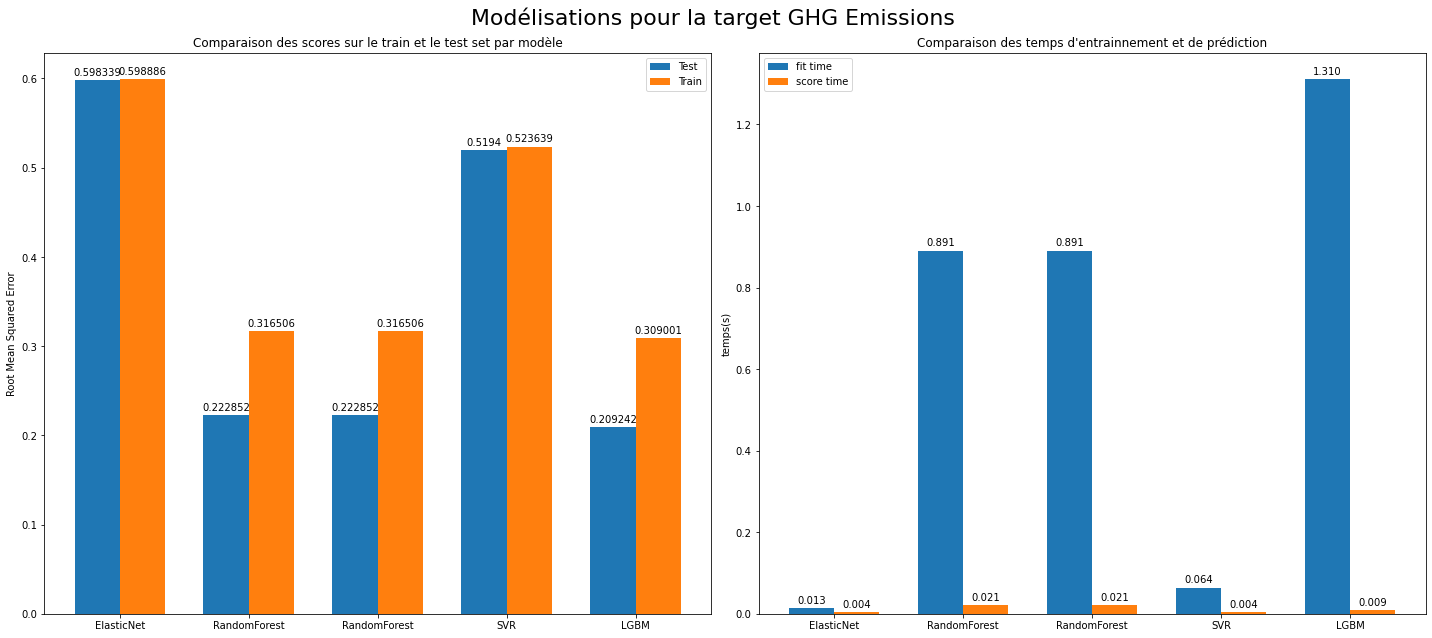

Durée d'exécution de affiche_modelisations: 0.6702761650085449s


In [55]:
affiche_modelisations(resultat_co2_grid, "GHG Emissions")


## Features importance 

In [ ]:
rf_co2_optimal = rf_co2.best_estimator_

In [68]:
# Affichage des features importance
def affic_features_impotance_model(model,  X_test, name):
    
    feat_imp = model.feature_importances_
    df_featimp = pd.DataFrame(feat_imp, columns = {"Feature Importance"})
    df_featimp["Feature Name"] = X_test.columns
    df_featimp = df_featimp.sort_values(by="Feature Importance", ascending=True)
    display(df_featimp)
    
    # Affichage Features importance
    plt.figure(figsize=(10,7))
    #df_featimp.plot.bar(x= "Feature Importance", y = "Feature Name", title =f"Feature importance pour le modele {name} ")
    #plt.barh(X_test.columns, feat_imp)
    plt.barh(df_featimp["Feature Name"], df_featimp["Feature Importance"])
    plt.xlabel("Feature Importance")
    plt.title(f"Feature importance pour le modele {name} ")
    plt.show()

    return None

,Feature Importance,Feature Name
5,0.005764,ThirdLargestPropertyUseType
17,0.006217,NumberOfAllUseTypes
16,0.007141,RateThirdLargestPropertyUseType
11,0.007413,RateBuilding
8,0.007738,Electricity(kBtu)
4,0.008378,SecondLargestPropertyUseType
10,0.008528,RateParking
15,0.012984,RateSecondLargestPropertyUseType
2,0.019973,Neighborhood
14,0.021905,RateLargestPropertyUseType


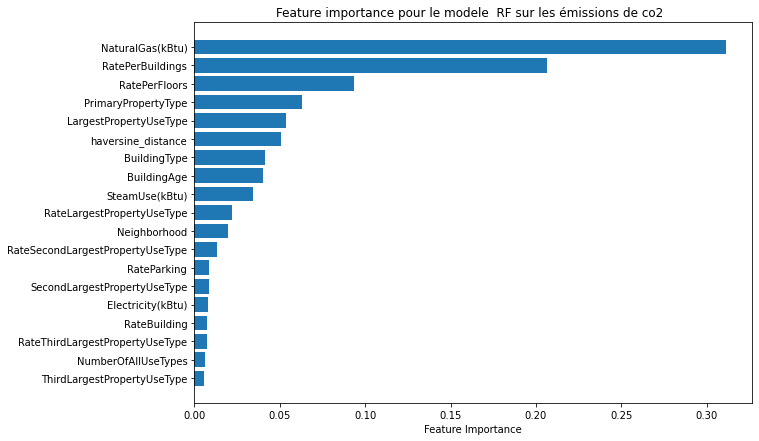

In [69]:
affic_features_impotance_model(rf_co2_optimal, X_Co2_test, " RF sur les émissions de co2 ")


On note que :

>l'électricité,

>le nombre total de type d'usage

>la surface du bâtiment,

>l'utilisation de vapeur

>le type de bâtiment type d'énergie,

*n'influencent pas beaucoup (<0.05) sur les émissions de Co2.*

# Pistes d'amélioration :

## L'interêt de l'EnergieStar Score : 

### Dataset pour l'étude de l'Energy Star


In [12]:
data_ES= data.dropna(subset = "ENERGYSTARScore")


In [13]:
## Sélectionner les variables catégorielles et numériques

categorical_ES = data_ES.select_dtypes(exclude = "number").columns.tolist()

numerical_ES = data_ES.select_dtypes(include = "number").columns.tolist()

## Suppression des variables cibles de la liste des variables numériques (ce sont des variables cibles dans la modélisation, et elles ne doivent pas être utilisées comme features pour les modèles prédictifs.)

numerical_ES.remove("SiteEnergyUse(kBtu)Log")
numerical_ES.remove("TotalGHGEmissionsLog")

### Séparation en train et test set


In [14]:
#Target consommation totale en énergie
X_Site_ES_log = data_ES.drop(columns = ["SiteEnergyUse(kBtu)Log", "TotalGHGEmissionsLog"])
y_Site_ES_log = data_ES["SiteEnergyUse(kBtu)Log"]

# Séparation en train et test (80% train, 20% test)
X_site_ES_train, X_site_ES_test, y_site_ES_train, y_site_ES_test = train_test_split(X_Site_ES_log, y_Site_ES_log, test_size=0.2, random_state=seed)

#Target émissions de Co2
X_Co2_ES_log = data_ES.drop(columns = [ "TotalGHGEmissionsLog", "SiteEnergyUse(kBtu)Log"])
y_Co2_ES_log = data_ES["TotalGHGEmissionsLog"]

# Séparation en train et test pour les émissions de CO2
X_Co2_ES_train, X_Co2_ES_test, y_Co2_ES_train, y_Co2_ES_test = train_test_split(X_Co2_ES_log, y_Co2_ES_log, test_size=0.2, random_state=seed)

In [18]:
## Identification des variables catégorielles et numériques

categorical = model_data.select_dtypes(exclude = "number").columns.tolist()

numerical = model_data.select_dtypes(include = "number").columns.tolist()

# Suppression des cibles dans les variables numériques
numerical.remove("SiteEnergyUse(kBtu)Log")
numerical.remove("TotalGHGEmissionsLog")

### Encodage 

In [78]:
X_site_ES_train[categorical_ES]= encoder.fit_transform(X_site_ES_train[categorical_ES], y_site_ES_train)
X_site_ES_test[categorical_ES]= encoder.fit_transform(X_site_ES_test[categorical_ES], y_site_ES_test)


X_Co2_ES_train[categorical_ES]=encoder.fit_transform(X_Co2_ES_train[categorical_ES], y_Co2_ES_train)
X_Co2_ES_test[categorical_ES]=encoder.fit_transform(X_Co2_ES_test[categorical_ES], y_Co2_ES_test)

### Standarisation 

In [79]:
X_site_ES_train[numerical_ES]= scaler.fit_transform(X_site_ES_train[numerical_ES])
X_site_ES_test[numerical_ES]= scaler.fit_transform(X_site_ES_test[numerical_ES])


X_Co2_ES_train[numerical_ES]=scaler.fit_transform(X_Co2_ES_train[numerical_ES])
X_Co2_ES_test[numerical_ES]=scaler.fit_transform(X_Co2_ES_test[numerical_ES])

### Entrainement et Cross Validation 

In [80]:
rf_co2_ES = gridCV(RandomForestRegressor(), random_parameters, X_Co2_ES_train, y_Co2_ES_train,5)


Durée d'exécution de gridCV: 1115.3837807178497s


In [81]:
rf_res_ES = resultats_grid(rf_co2_ES, "RF_ES_Co2",X_Co2_ES_train, y_Co2_ES_train)


Durée d'exécution de resultats_grid: 0.07986307144165039s


In [82]:
rf_ES = gridCV(RandomForestRegressor(), random_parameters, X_site_ES_train, y_site_ES_train,5)


Durée d'exécution de gridCV: 1089.9255092144012s


In [83]:
rf_result = resultats_grid(rf_ES, "RF_ES_SEU", X_site_ES_train, y_site_ES_train)


Durée d'exécution de resultats_grid: 0.1844031810760498s


In [84]:
res_ES = pd.concat([rf_res_ES,rf_result], ignore_index=True)


Entrainons le modèle sur le meme nombre de données : 

In [86]:
X_ES_site_train = X_site_ES_train.drop(['ENERGYSTARScore'], axis = 1)
X_ES_site_test = X_site_ES_test.drop(['ENERGYSTARScore'], axis = 1)

X_ES_co2_train = X_Co2_ES_train.drop(['ENERGYSTARScore'], axis = 1)
X_ES_co2_test = X_Co2_ES_test.drop(['ENERGYSTARScore'], axis = 1)

rf_co2_ES_total = gridCV(RandomForestRegressor(), random_parameters, X_ES_co2_train, y_Co2_ES_train,5)
rf_res_ES_total = resultats_grid(rf_co2_ES_total, "RF_ES_Co2 sans ES",X_ES_co2_train, y_Co2_ES_train)
res_ES = pd.concat([res_ES,rf_res_ES_total], ignore_index=True)



rf_ES_total = gridCV(RandomForestRegressor(), random_parameters, X_ES_site_train, y_site_ES_train,5)
rf_result_total = resultats_grid(rf_ES_total, "RF_ES_SEU sans ES", X_ES_site_train, y_site_ES_train)
res_ES = pd.concat([res_ES,rf_result_total], ignore_index=True)


Durée d'exécution de gridCV: 933.9859101772308s
Durée d'exécution de resultats_grid: 0.07810449600219727s
Durée d'exécution de gridCV: 900.1057872772217s
Durée d'exécution de resultats_grid: 0.08910179138183594s


## Comparaison 

In [87]:
res_ES.style.hide_index()


modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
RF_ES_Co2,0.717809,0.020579,0.197740,0.285512,"{'bootstrap': False, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}",0.083609
RF_ES_SEU,0.699640,0.020241,0.147983,0.212063,"{'bootstrap': False, 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}",0.000729
RF_ES_Co2 sans ES,0.602577,0.016498,0.207254,0.294619,"{'bootstrap': False, 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5}",0.102271
RF_ES_SEU sans ES,0.579087,0.016276,0.162412,0.230478,"{'bootstrap': False, 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}",0.044309


<AxesSubplot:xlabel='modèle'>

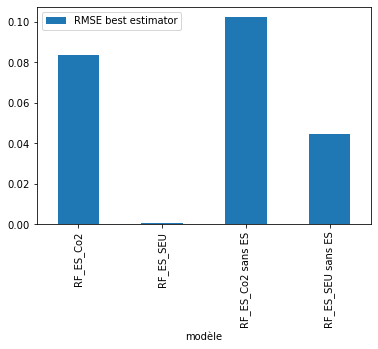

In [88]:
res_ES.plot.bar(x= "modèle", y="RMSE best estimator" )


>Le score pour *la consommation d'énergie* s'est amélioré.

>Le score pour *les émissions de Co2* s'est légerement amélioré.

Cette amélioration peut être aidé par le faible nombre de données.

Elle découle aussi du fait que l'energy star est calculé à l'aide des source d'energies du bâtiment.

## Features Importance

,Feature Importance,Feature Name
9,0.001784,Electricity(kBtu)
12,0.006253,RateBuilding
11,0.006610,RateParking
17,0.007177,RateThirdLargestPropertyUseType
5,0.007332,ThirdLargestPropertyUseType
4,0.008487,SecondLargestPropertyUseType
18,0.008560,NumberOfAllUseTypes
16,0.011526,RateSecondLargestPropertyUseType
2,0.019450,Neighborhood
15,0.020499,RateLargestPropertyUseType


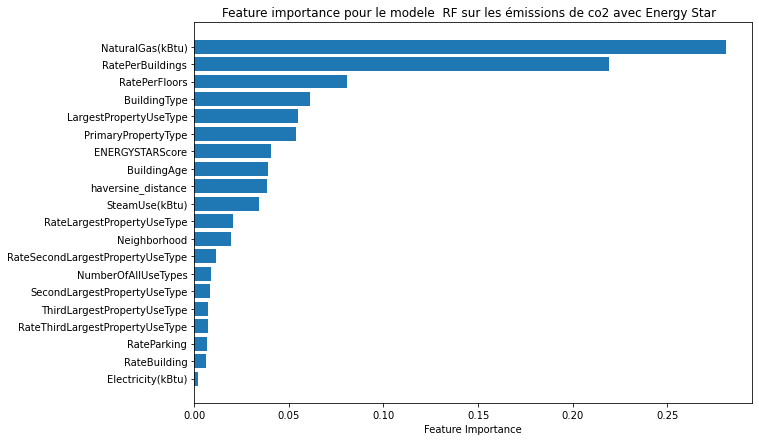

In [90]:
rf_co2_ES_model = rf_co2_ES.best_estimator_
rf_site_ES_model = rf_ES.best_estimator_

affic_features_impotance_model(rf_co2_ES_model, X_Co2_ES_test," RF sur les émissions de co2 avec Energy Star ")

,Feature Importance,Feature Name
9,0.000087,Electricity(kBtu)
8,0.006628,SteamUse(kBtu)
4,0.010790,SecondLargestPropertyUseType
12,0.011169,RateBuilding
11,0.011912,RateParking
17,0.012912,RateThirdLargestPropertyUseType
16,0.013628,RateSecondLargestPropertyUseType
18,0.014038,NumberOfAllUseTypes
5,0.019671,ThirdLargestPropertyUseType
15,0.023916,RateLargestPropertyUseType


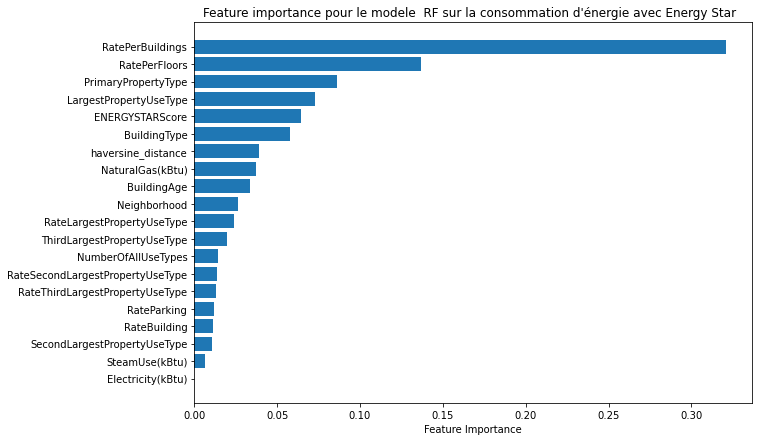

In [91]:
affic_features_impotance_model(rf_site_ES_model, X_site_ES_test, " RF sur la consommation d'énergie avec Energy Star ")


>On remarque la bonne position du score , 2eme pour la consommation totale des bâtiments et 4eme pour les émissions de Co2.
On en déduit que l'energy star score est pertinent pour prédire la consommation en énergie des bâtiments, un peu moins mais tout de même pertinent aussi pour les émissions de Co2.